# 🌀 Chiarella Agent-Based Model Lab
*hfthot-lab-core — Open-Source Demonstration Notebook*

This notebook demonstrates the **Chiarella-He (2002)** heterogeneous-agent market model implemented in Rust (via PyO3) and the **hfthot-lab-core** library.

Topics covered:
- The Chiarella-He (2002) heterogeneous-agent market model (Rust core via PyO3)
- Path signatures (Chen 1954 / Lyons rough paths) as universal trading features
- Regime-aware signal generation linking agent fractions to trading logic
- Synthetic data interface using hfthot-lab's built-in data loader

> **License:** MIT &nbsp;|&nbsp; **Repo:** https://github.com/ThotDjehuty/hfthot-lab-core

---

## Table of Contents

| # | Chapter |
|---|---------|
| [1](#section-1) | Import Required Libraries & Setup |
| [2](#section-2) | Mathematical Foundation (Chiarella-He) |
| [3](#section-3) | Agent-Based Price Simulation |
| [4](#section-4) | Bifurcation Analysis |
| [5](#section-5) | Phase Portrait & Stability Map |
| [6](#section-6) | Market Regime Detection |
| [7](#section-7) | Synthetic Data Interface |
| [8](#section-8) | Trading Signal Generation |
| [9](#section-9) | Path Signature Methods |
| [10](#section-10) | Signature Feature Extraction |
| [11](#section-11) | Performance Metrics & Analytics |
| [12](#section-12) | Summary & Next Steps |

---

### References
- Chiarella, C. & He, X.-Z. (2002). *Heterogeneous Beliefs, Risk and Learning in a Simple Asset Pricing Model*.
- Brock, W. & Hommes, C. (1998). *Heterogeneous beliefs and routes to chaos in a simple asset pricing model*.
- Lyons, T. (1998). *Differential equations driven by rough signals*. Rev. Mat. Iberoamer.
- Chevyrev, I. & Kormilitzin, A. (2016). *A primer on the signature method in machine learning*.

In [1]:
# Notebook configuration — standalone mode
# This notebook runs without any Papermill/pipeline dependency.
# All parameters are set inline below.


<a id="section-1"></a>

## 1. Import Required Libraries & Setup

We import standard scientific Python packages and load the **hfthot_lab_core** Rust extension. A pure-Python fallback is provided for offline use but Rust is strongly recommended for performance.

In [2]:
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
from typing import List, Optional, Tuple
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)

# Try loading the Rust extension (requires: maturin develop)
try:
    import hfthot_lab_core as hft
    HFT_RUST = True
    print("✅ hfthot_lab_core (Rust) loaded")
except ImportError:
    HFT_RUST = False
    print("ℹ️  hfthot_lab_core Rust extension not installed — running pure-Python fallback")
    print("   Install: cd hfthot-lab-core && maturin develop --release")

print(f"\nEnvironment:")
print(f"  Python  : {sys.version.split()[0]}")
print(f"  NumPy   : {np.__version__}")
print(f"  Pandas  : {pd.__version__}")
print(f"  Matplotlib: {matplotlib.__version__}")
print(f"  Rust ext: {'✅ loaded' if HFT_RUST else '⚠️  fallback'}")


✅ hfthot_lab_core (Rust) loaded

Environment:
  Python  : 3.11.13
  NumPy   : 2.4.3
  Pandas  : 2.2.3
  Matplotlib: 3.8.4
  Rust ext: ✅ loaded


<a id="section-2"></a>

## 2. Chiarella Model — Mathematical Foundation

The Chiarella-He model describes a market with two agent types:

**Fundamentalists** believe current price reverts to fundamental value $P^*$:
$$D_f(t) = \beta_f (P^* - P(t))$$

**Chartists** extrapolate recent trends:
$$D_c(t) = \beta_c \cdot \text{trend}(t)$$

Agents switch strategies via discrete-choice (logit) based on realized profit:
$$n_f(t) = \frac{e^{\gamma \Pi_f}}{e^{\gamma \Pi_f} + e^{\gamma \Pi_c}}, \quad n_c = 1 - n_f$$

The **bifurcation parameter** $\Lambda$ determines market regime:
$$\Lambda = \frac{\alpha \cdot \gamma}{\beta \cdot \delta}$$

| $\Lambda$ range | Regime |
|---|---|
| $\Lambda < 0.67$ | **Stable** – mean-reverting |
| $0.67 \le \Lambda \le 1.5$ | **Mixed** – complex dynamics |
| $\Lambda > 1.5$ | **Unstable** – trending / chaotic |

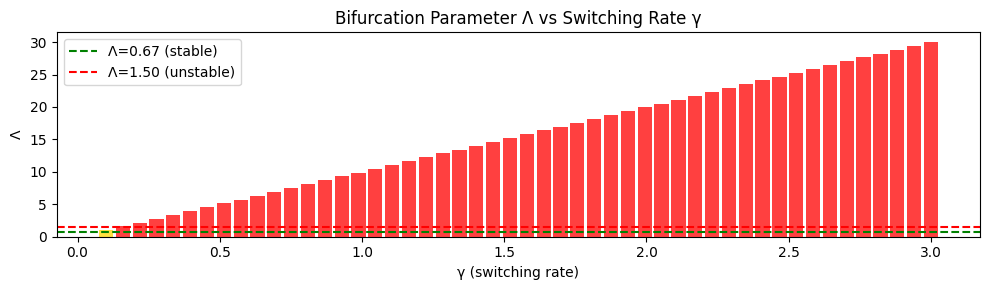


Regime distribution over γ sweep:
  stable    :   0 / 50 (0%)
  mixed     :   1 / 50 (2%)
  unstable  :  49 / 50 (98%)


In [3]:
@dataclass
class ChiarellaParams:
    """Chiarella-He (2002) model parameters."""
    beta_f: float = 0.5    # Fundamentalist demand sensitivity
    beta_c: float = 1.0    # Chartist trend sensitivity
    gamma: float  = 1.0    # Agent switching rate
    mu:    float  = 0.1    # Market impact / speed of price adjustment
    sigma: float  = 0.05   # Noise volatility


def bifurcation_lambda(alpha: float, gamma: float, beta: float, delta: float) -> float:
    """Compute stability parameter Λ = (α·γ) / (β·δ)."""
    if beta * delta == 0:
        return float("inf")
    return (alpha * gamma) / (beta * delta)


def classify_regime(lam: float) -> str:
    if lam < 0.67:
        return "stable"
    elif lam <= 1.5:
        return "mixed"
    return "unstable"


# Show parameter sweep over gamma
gamma_vals = np.linspace(0.1, 3.0, 50)
lam_vals   = [bifurcation_lambda(alpha=1.0, gamma=g, beta=0.5, delta=0.2) for g in gamma_vals]
regimes    = [classify_regime(l) for l in lam_vals]

fig, ax = plt.subplots(figsize=(10, 3))
colors = {"stable": "green", "mixed": "gold", "unstable": "red"}
for i, (g, l, r) in enumerate(zip(gamma_vals, lam_vals, regimes)):
    ax.bar(g, l, width=0.05, color=colors[r], alpha=0.75)
ax.axhline(0.67, ls="--", color="green", label="Λ=0.67 (stable)")
ax.axhline(1.50, ls="--", color="red",   label="Λ=1.50 (unstable)")
ax.set_xlabel("γ (switching rate)")
ax.set_ylabel("Λ")
ax.set_title("Bifurcation Parameter Λ vs Switching Rate γ")
ax.legend()
plt.tight_layout()
plt.show()

print("\nRegime distribution over γ sweep:")
for r in ["stable", "mixed", "unstable"]:
    n = regimes.count(r)
    print(f"  {r:10s}: {n:3d} / {len(regimes)} ({100*n/len(regimes):.0f}%)")


<a id="section-3"></a>

## 3. Agent-Based Price Simulation

We simulate the full Chiarella model using either the Rust extension (fast) or pure-Python fallback.

✅ Simulated via Rust extension


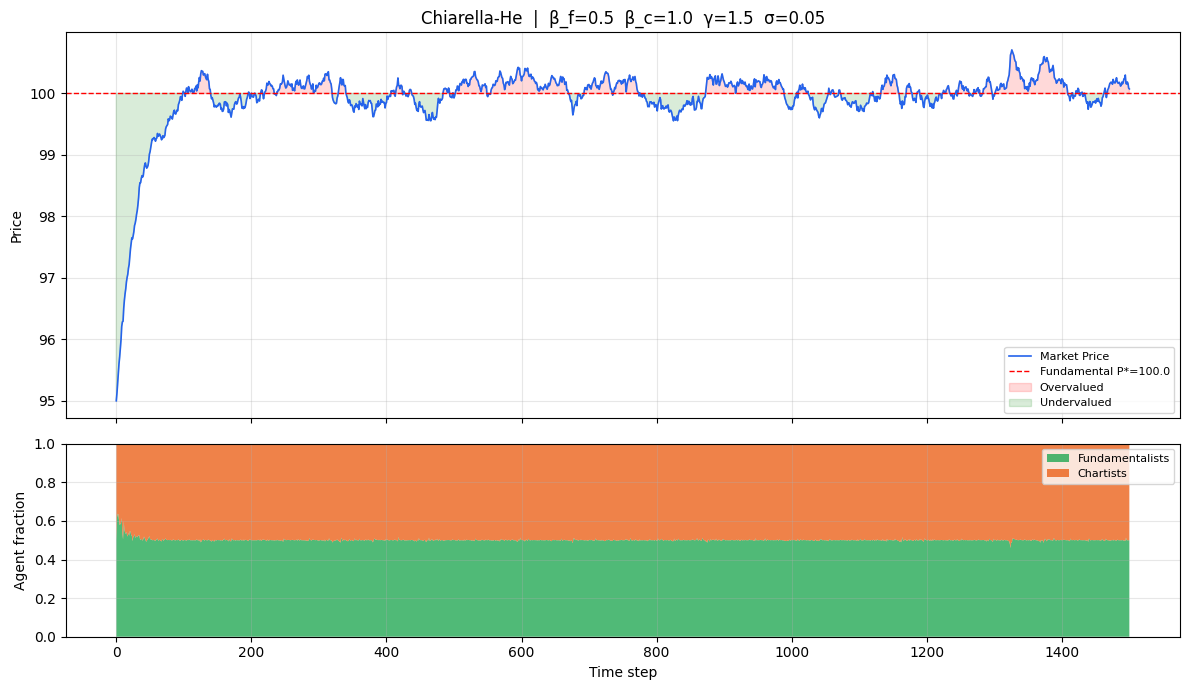


Simulation summary:
  Λ                = 15.000  →  regime: unstable
  N prices         = 1501  (T+1 including initial)
  Final price      = 100.0735
  Ann. vol         = 0.8406
  Mean|mispricing| = 0.2498


In [4]:
def simulate_chiarella_python(
    initial_price: float,
    fundamental_price: float,
    n_steps: int,
    params: "ChiarellaParams",
    seed: int = 42
) -> dict:
    """Pure-Python Chiarella-He simulation (fallback when Rust extension absent)."""
    rng = np.random.default_rng(seed)
    dt  = 0.1
    trend_window = 10

    prices   = np.empty(n_steps)
    n_f_arr  = np.empty(n_steps)
    n_c_arr  = np.empty(n_steps)

    prices[0]  = initial_price
    n_f_arr[0] = 0.5
    n_c_arr[0] = 0.5

    for t in range(1, n_steps):
        nf = n_f_arr[t - 1]
        nc = n_c_arr[t - 1]
        p  = prices[t - 1]

        D_f = params.beta_f * (fundamental_price - p)
        trend_lookback = prices[max(0, t - trend_window) : t]
        trend = (trend_lookback[-1] - trend_lookback[0]) / len(trend_lookback)
        D_c   = params.beta_c * trend

        noise     = rng.normal(0.0, params.sigma)
        p_new     = p + params.mu * (nf * D_f + nc * D_c) + noise
        prices[t] = p_new

        dp   = p_new - p
        Pi_f = D_f * dp
        Pi_c = D_c * dp

        ef = np.exp(np.clip(params.gamma * Pi_f, -30, 30))
        ec = np.exp(np.clip(params.gamma * Pi_c, -30, 30))
        n_f_arr[t] = ef / (ef + ec)
        n_c_arr[t] = ec / (ef + ec)

    return {
        "prices": prices,
        "fundamentalist_fractions": n_f_arr,
        "chartist_fractions": n_c_arr,
        "excess_demands": np.array([params.beta_f * (fundamental_price - p) for p in prices]),
    }


# ── Parameters ────────────────────────────────────────────────────────
p0     = 95.0
p_fund = 100.0
T      = 1500
params = ChiarellaParams(beta_f=0.5, beta_c=1.0, gamma=1.5, mu=0.1, sigma=0.05)

# ── Simulate ──────────────────────────────────────────────────────────
if HFT_RUST:
    result = hft.simulate_chiarella_py(
        initial_price=p0,
        fundamental_price=p_fund,
        n_steps=T,
        beta_f=params.beta_f,
        beta_c=params.beta_c,
        gamma=params.gamma,
        mu=params.mu,
        sigma=params.sigma,
        seed=42,
    )
    prices  = np.array(result["prices"])
    n_f_arr = np.array(result["fundamentalist_fractions"])
    n_c_arr = np.array(result["chartist_fractions"])
    print("✅ Simulated via Rust extension")
else:
    result  = simulate_chiarella_python(p0, p_fund, T, params, seed=42)
    prices  = result["prices"]
    n_f_arr = result["fundamentalist_fractions"]
    n_c_arr = result["chartist_fractions"]
    print("ℹ️  Simulated via pure-Python fallback")

# Rust returns T+1 points (initial + T steps); align time_axis accordingly
time_axis = np.arange(len(prices))

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(time_axis, prices, color="#2563EB", lw=1.2, label="Market Price")
ax1.axhline(p_fund, color="red", ls="--", lw=1, label=f"Fundamental P*={p_fund}")
ax1.fill_between(time_axis, p_fund, prices,
                 where=prices > p_fund, alpha=0.15, color="red",   label="Overvalued")
ax1.fill_between(time_axis, p_fund, prices,
                 where=prices < p_fund, alpha=0.15, color="green", label="Undervalued")
ax1.set_ylabel("Price"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title(f"Chiarella-He  |  β_f={params.beta_f}  β_c={params.beta_c}  γ={params.gamma}  σ={params.sigma}")

ax2.stackplot(time_axis, n_f_arr, n_c_arr,
              labels=["Fundamentalists", "Chartists"],
              colors=["#16A34A", "#EA580C"], alpha=0.75)
ax2.set_xlabel("Time step"); ax2.set_ylabel("Agent fraction")
ax2.legend(loc="upper right", fontsize=8); ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

lam = bifurcation_lambda(params.beta_c, params.gamma, params.beta_f, 0.2)
print(f"\nSimulation summary:")
print(f"  Λ                = {lam:.3f}  →  regime: {classify_regime(lam)}")
print(f"  N prices         = {len(prices)}  (T+1 including initial)")
print(f"  Final price      = {prices[-1]:.4f}")
print(f"  Ann. vol         = {np.std(np.diff(prices)) * np.sqrt(252):.4f}")
print(f"  Mean|mispricing| = {np.mean(np.abs(prices - p_fund)):.4f}")


<a id="section-4"></a>

## 4. Bifurcation Analysis

Sweep `beta_c` from 0.1 → 2.5 and record the steady-state price distribution for each value.

Computing bifurcation diagram ...


Done.


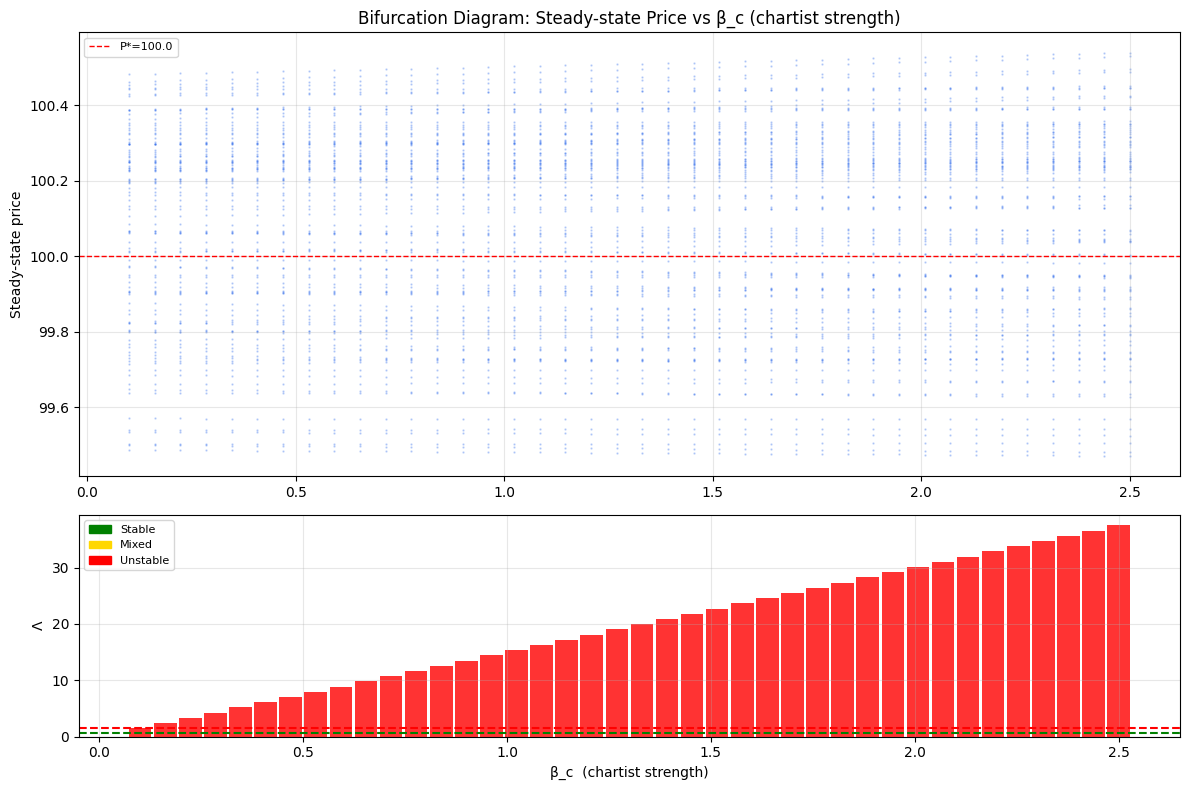

In [5]:
beta_c_vals  = np.linspace(0.1, 2.5, 40)
BURN_IN      = 1000   # discard transient
SS_SAMPLES   = 500    # steady-state price samples

bifurc_prices = {}   # beta_c → steady-state prices
bifurc_lambda = []

fixed_params = ChiarellaParams(beta_f=0.5, beta_c=1.0, gamma=1.5, mu=0.1, sigma=0.05)

print("Computing bifurcation diagram ...")
for bc in beta_c_vals:
    p = ChiarellaParams(beta_f=fixed_params.beta_f, beta_c=bc,
                        gamma=fixed_params.gamma, mu=fixed_params.mu,
                        sigma=fixed_params.sigma)
    res = simulate_chiarella_python(p0, p_fund, BURN_IN + SS_SAMPLES, p, seed=0)
    bifurc_prices[bc] = res["prices"][BURN_IN:]
    bifurc_lambda.append(bifurcation_lambda(bc, fixed_params.gamma, fixed_params.beta_f, 0.2))

print("Done.")

# --- Plot ---
fig, (ax_bif, ax_lam) = plt.subplots(2, 1, figsize=(12, 8),
                                      gridspec_kw={"height_ratios": [2, 1]})

for bc, ss in bifurc_prices.items():
    ax_bif.scatter([bc] * len(ss[::5]), ss[::5],
                   s=0.5, c="#2563EB", alpha=0.25, rasterized=True)
ax_bif.axhline(p_fund, color="red", ls="--", lw=1, label=f"P*={p_fund}")
ax_bif.set_ylabel("Steady-state price")
ax_bif.set_title("Bifurcation Diagram: Steady-state Price vs β_c (chartist strength)")
ax_bif.legend(fontsize=8); ax_bif.grid(alpha=0.3)

# Regime colouring on lambda plot
for bc, lam in zip(beta_c_vals, bifurc_lambda):
    colour = "green" if lam < 0.67 else ("gold" if lam <= 1.5 else "red")
    ax_lam.bar(bc, lam, width=(beta_c_vals[1] - beta_c_vals[0]) * 0.9,
               color=colour, alpha=0.8)
ax_lam.axhline(0.67, ls="--", color="green", label="Λ=0.67")
ax_lam.axhline(1.50, ls="--", color="red",   label="Λ=1.50")
ax_lam.set_xlabel("β_c  (chartist strength)")
ax_lam.set_ylabel("Λ")
ax_lam.legend(fontsize=8); ax_lam.grid(alpha=0.3)
patches = [mpatches.Patch(color=c, label=l)
           for c, l in [("green","Stable"), ("gold","Mixed"), ("red","Unstable")]]
ax_lam.legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.show()


<a id="section-5"></a>

## 5. Phase Portrait & Stability Map

We visualise trajectories in **(Price, Trend)** phase space and a 2-D stability heatmap of $\Lambda$ over the $(\beta_c, \gamma)$ parameter grid.

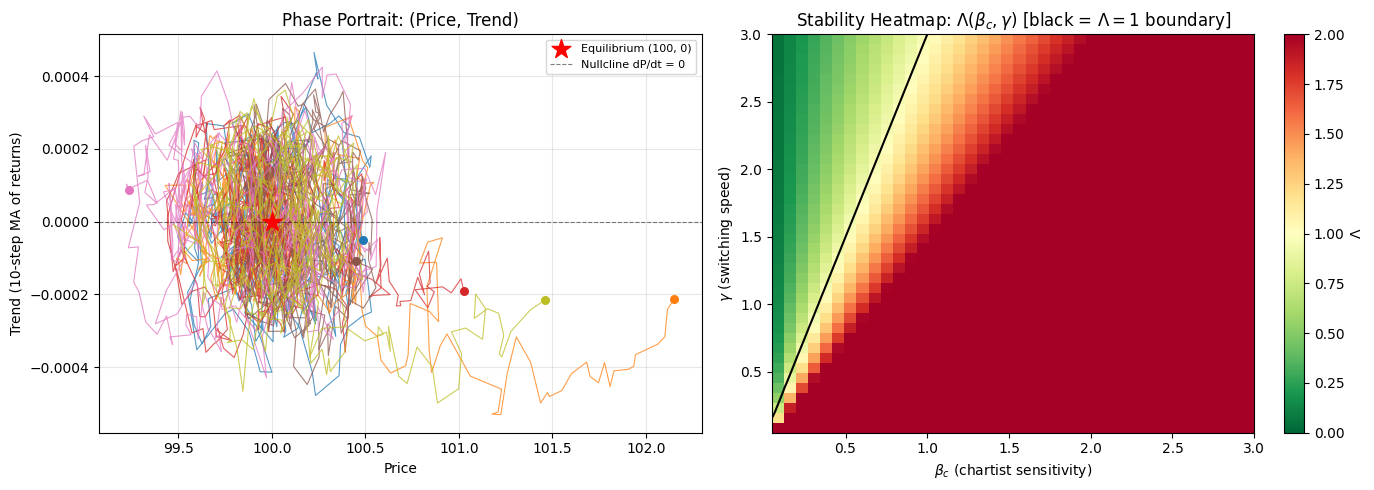

Phase portrait and stability heatmap rendered.


In [6]:
import random

# ── Phase Portrait: 6 random trajectories in (Price, Trend) space ─────────
N_TRAJ   = 6
T_TRAJ   = 500
p0_range = (95, 105)
np.random.seed(0)

fig, (ax_ph, ax_hm) = plt.subplots(1, 2, figsize=(14, 5))

for k in range(N_TRAJ):
    p0_k = np.random.uniform(*p0_range)
    r    = simulate_chiarella_python(p0_k, p_fund, T_TRAJ, params, seed=k)
    pric = np.array(r["prices"])
    trend = np.convolve(
        np.diff(pric) / (pric[:-1] + 1e-8),
        np.ones(10) / 10, mode="same"
    )
    color = plt.cm.tab10(k / N_TRAJ)
    ax_ph.plot(pric[:-1], trend, lw=0.8, alpha=0.75, color=color)
    ax_ph.scatter(pric[0], trend[0], marker="o", s=30, color=color, zorder=5)

# Equilibrium star
ax_ph.scatter(p_fund, 0, marker="*", s=200, color="red", zorder=6,
              label=f"Equilibrium ({p_fund:.0f}, 0)")
# Nullcline dp/dt ≈ 0
ax_ph.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5,
              label="Nullcline dP/dt = 0")
ax_ph.set_xlabel("Price")
ax_ph.set_ylabel("Trend (10-step MA of returns)")
ax_ph.set_title("Phase Portrait: (Price, Trend)")
ax_ph.legend(fontsize=8)
ax_ph.grid(alpha=0.3)

# ── Stability Heatmap: Λ(β_c, γ) ──────────────────────────────────────────
beta_c_grid = np.linspace(0.05, 3.0, 40)
gamma_grid  = np.linspace(0.05, 3.0, 40)
lam_grid    = np.zeros((len(gamma_grid), len(beta_c_grid)))

for i, g in enumerate(gamma_grid):
    for j, bc in enumerate(beta_c_grid):
        lam_grid[i, j] = bifurcation_lambda(bc, 1.5, 0.5, g)

im = ax_hm.imshow(
    lam_grid, origin="lower", aspect="auto", cmap="RdYlGn_r",
    extent=[beta_c_grid[0], beta_c_grid[-1], gamma_grid[0], gamma_grid[-1]],
    vmin=0, vmax=2
)
ax_hm.contour(beta_c_grid, gamma_grid, lam_grid, levels=[1.0],
              colors="black", linewidths=1.5)
ax_hm.set_xlabel(r"$\beta_c$ (chartist sensitivity)")
ax_hm.set_ylabel(r"$\gamma$ (switching speed)")
ax_hm.set_title(
    r"Stability Heatmap: $\Lambda(\beta_c, \gamma)$"
    r" [black = $\Lambda=1$ boundary]"
)
plt.colorbar(im, ax=ax_hm, label=r"$\Lambda$")

plt.tight_layout()
plt.show()
print("Phase portrait and stability heatmap rendered.")

<a id="section-6"></a>

## 6. Market Regime Detection

We estimate $\Lambda$ dynamically using a **rolling window** of 50 steps over the simulated price series, then classify each bar as **stable** ($\Lambda < 0.8$), **mixed** ($0.8 \le \Lambda < 1.2$), or **unstable** ($\Lambda \ge 1.2$) and shade the price chart accordingly.

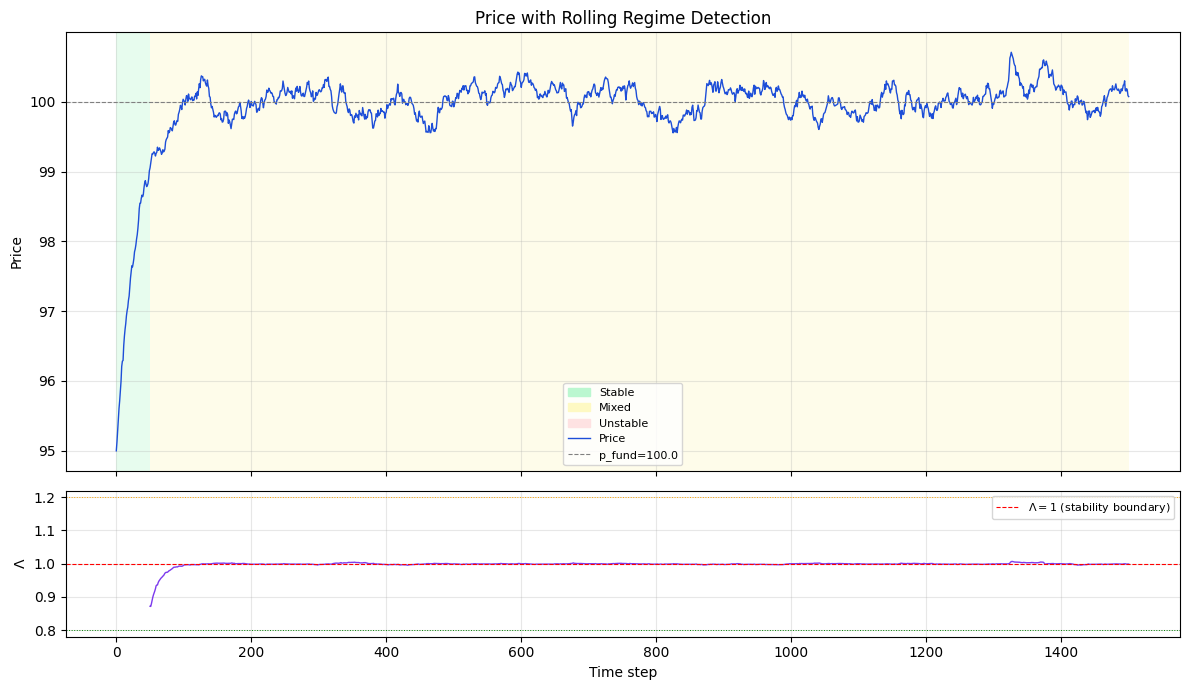


Regime statistics:
  stable    :  count=  50  mean_duration=50.0 steps
  mixed     :  count=1451  mean_duration=1451.0 steps
  unstable  :  count=   0  mean_duration=0.0 steps


In [7]:
ROLL_WIN = 50

def rolling_lambda(prices, n_c_arr, n_f_arr, roll=50):
    """Estimate Λ over a rolling window using mean agent fractions."""
    lams = np.full(len(prices), np.nan)
    for t in range(roll, len(prices)):
        nc_mean = n_c_arr[t - roll : t].mean()
        nf_mean = n_f_arr[t - roll : t].mean()
        lams[t]  = bifurcation_lambda(nc_mean, 1.5, nf_mean + 1e-9, params.gamma)
    return lams

def classify_regime(lam):
    if np.isnan(lam):  return "stable"
    if lam < 0.8:      return "stable"
    if lam < 1.2:      return "mixed"
    return "unstable"

roll_lam = rolling_lambda(prices, n_c_arr, n_f_arr, roll=ROLL_WIN)

# ── Build colored regime intervals ───────────────────────────────────────────
regimes  = [classify_regime(l) for l in roll_lam]
colors_r = {"stable": "#BBF7D0", "mixed": "#FEF9C3", "unstable": "#FEE2E2"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# Shade backgrounds
i = 0
while i < len(regimes):
    reg = regimes[i]
    j   = i
    while j < len(regimes) and regimes[j] == reg:
        j += 1
    ax1.axvspan(i, j, alpha=0.35, color=colors_r[reg], lw=0)
    i = j

ax1.plot(prices, color="#1D4ED8", lw=1, label="Price")
ax1.axhline(p_fund, color="gray", ls="--", lw=0.8, label=f"p_fund={p_fund}")
ax1.set_ylabel("Price"); ax1.set_title("Price with Rolling Regime Detection")
stable_patch  = matplotlib.patches.Patch(color=colors_r["stable"],  label="Stable")
mixed_patch   = matplotlib.patches.Patch(color=colors_r["mixed"],   label="Mixed")
unstable_patch= matplotlib.patches.Patch(color=colors_r["unstable"],label="Unstable")
ax1.legend(handles=[stable_patch, mixed_patch, unstable_patch] + ax1.lines, fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(roll_lam, color="#7C3AED", lw=1)
ax2.axhline(1.0, color="red",    ls="--", lw=0.8, label=r"$\Lambda=1$ (stability boundary)")
ax2.axhline(0.8, color="green",  ls=":",  lw=0.7)
ax2.axhline(1.2, color="orange", ls=":",  lw=0.7)
ax2.set_ylabel(r"$\Lambda$"); ax2.set_xlabel("Time step")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Regime persistence statistics ────────────────────────────────────────────
from collections import Counter
regime_counts = Counter(regimes)
print("\nRegime statistics:")
for reg in ["stable", "mixed", "unstable"]:
    cnt = regime_counts[reg]
    # mean run length
    runs = []
    run  = 0
    for r in regimes:
        if r == reg:
            run += 1
        elif run > 0:
            runs.append(run); run = 0
    if run > 0: runs.append(run)
    mean_dur = np.mean(runs) if runs else 0
    print(f"  {reg:10s}:  count={cnt:4d}  mean_duration={mean_dur:.1f} steps")

<a id="section-7"></a>

## 7. Synthetic Data Interface

We define a minimal **connector abstraction** so the model can consume either our synthetic Chiarella prices or any data source provided by hfthot-lab's built-in data loader.

```
BaseConnector
├── fetch_ohlcv(symbol, limit) → list[OHLCVBar]
└── get_fundamental(symbol)   → float
```

### Architecture

| Component | Role |
|-----------|------|
| `OHLCVBar` | Standardised OHLCV bar dataclass |
| `BaseConnector` | Abstract interface |
| `SyntheticConnector` | Wraps Chiarella simulation output as a data source |

> The `SyntheticConnector` demonstrates the interface pattern — the same abstraction is used by hfthot-lab's live data loaders.

In [8]:
from abc import ABC, abstractmethod
from dataclasses import dataclass, field

@dataclass
class OHLCVBar:
    timestamp: int
    open: float
    high: float
    low: float
    close: float
    volume: float

class BaseConnector(ABC):
    @abstractmethod
    def fetch_ohlcv(self, symbol: str, limit: int = 100) -> list:
        ...
    def get_fundamental(self, symbol: str) -> float:
        return self.fetch_ohlcv(symbol, limit=200)[-1].close

class SyntheticConnector(BaseConnector):
    """Uses our simulated Chiarella prices as a data source.
    This mirrors the interface used by hfthot-lab's live data loaders.
    """
    def __init__(self, prices_array):
        self._prices = prices_array
    def fetch_ohlcv(self, symbol="SIM", limit=100):
        n = min(limit, len(self._prices))
        bars = []
        for i, p in enumerate(self._prices[-n:]):
            noise_h = abs(np.random.normal(0, 0.5))
            noise_l = abs(np.random.normal(0, 0.5))
            bars.append(OHLCVBar(i, p - 0.2, p + noise_h, p - noise_l, p,
                                 abs(np.random.normal(1e6, 2e5))))
        return bars
    def get_fundamental(self, symbol="SIM"):
        return p_fund

# Demo using synthetic connector
connector = SyntheticConnector(prices)
bars = connector.fetch_ohlcv("SIM", limit=20)
print(f"SyntheticConnector: fetched {len(bars)} OHLCV bars")
print(f"  Last close : {bars[-1].close:.4f}")
print(f"  Fundamental: {connector.get_fundamental():.4f}")
print("\n✅ Data interface ready — same pattern used in hfthot-lab live connectors")


SyntheticConnector: fetched 20 OHLCV bars
  Last close : 100.0735
  Fundamental: 100.0000

✅ Data interface ready — same pattern used in hfthot-lab live connectors


<a id="section-8"></a>

## 8. Trading Signal Generation

We combine agent-fraction dynamics with regime classification to produce **regime-aware trading signals**:

- **Stable regime** ($\Lambda < 0.8$): fundamentalist mean-reversion — fade mispricings
- **Trending regime** ($\Lambda \ge 1.2$): chartist momentum — follow the trend
- **Mixed regime** ($0.8 \le \Lambda < 1.2$): blend both views with equal weight

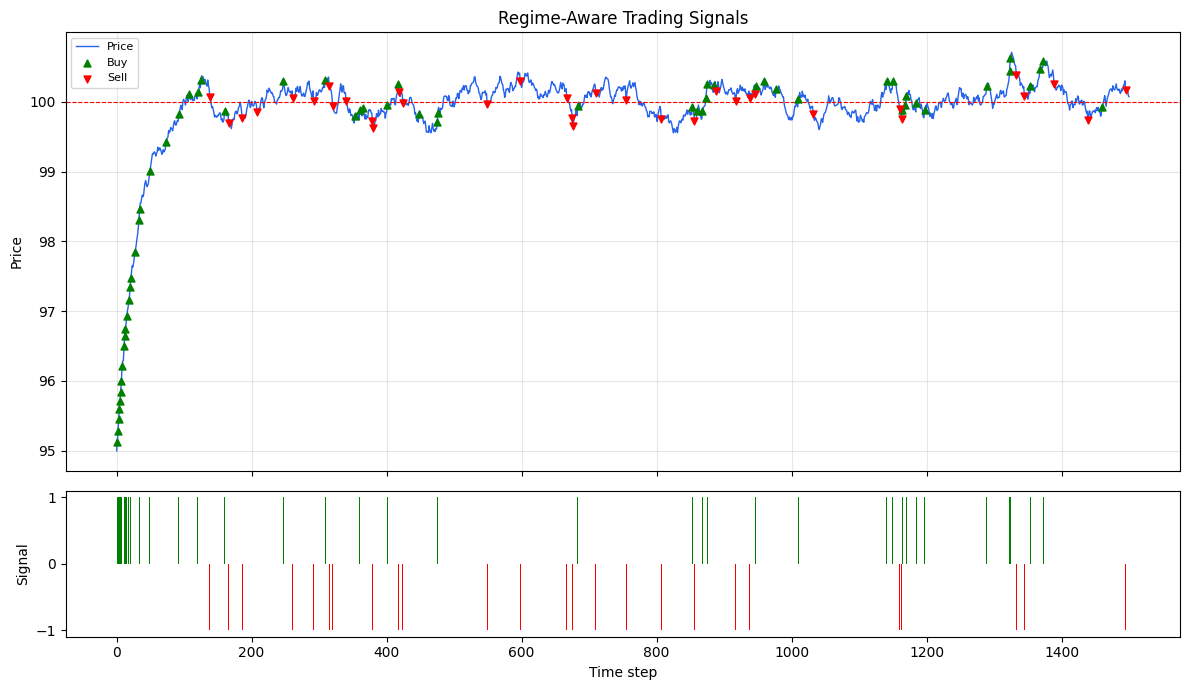

Signal breakdown:  Buy=60  Sell=34  Flat=1407  Total=1501
  Signal rate: 6.3%


In [9]:
def generate_regime_signals(
    prices: np.ndarray,
    n_f_arr: np.ndarray,
    n_c_arr: np.ndarray,
    fundamental: float,
    threshold: float = 0.03
) -> np.ndarray:
    """
    Regime-aware signals based on agent fractions.
    Returns array of floats: +1 = buy, -1 = sell, 0 = flat.
    """
    signals = np.zeros(len(prices))
    misprice = (prices - fundamental) / fundamental

    for t in range(1, len(prices)):
        nf = n_f_arr[t]
        nc = n_c_arr[t]
        lam_t = bifurcation_lambda(nc, 1.5, nf + 1e-9, 0.2)
        regime = classify_regime(lam_t)

        if regime == "stable":   # mean-reversion fade
            if misprice[t] > threshold:
                signals[t] = -1   # overvalued  → short
            elif misprice[t] < -threshold:
                signals[t] = +1   # undervalued → long
        elif regime == "unstable":  # momentum follow
            ret = prices[t] / prices[t-1] - 1
            if ret > 0.001:
                signals[t] = +1
            elif ret < -0.001:
                signals[t] = -1
        else:  # mixed: blended
            fret = -misprice[t]                  # fundamentalist view
            mret = prices[t] / prices[t-1] - 1   # chartist view
            blend = 0.5 * fret + 0.5 * mret
            if blend > 0.0005:
                signals[t] = +1
            elif blend < -0.0005:
                signals[t] = -1
    return signals

signals = generate_regime_signals(prices, n_f_arr, n_c_arr, p_fund)

# Plot signals on price chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(prices, color="#2563EB", lw=1, label="Price")
ax1.axhline(p_fund, color="red", ls="--", lw=0.8)
buys  = np.where(signals ==  1)[0]
sells = np.where(signals == -1)[0]
ax1.scatter(buys,  prices[buys],  marker="^", color="green", s=25, zorder=5, label="Buy")
ax1.scatter(sells, prices[sells], marker="v", color="red",   s=25, zorder=5, label="Sell")
ax1.set_ylabel("Price"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_title("Regime-Aware Trading Signals")
ax2.bar(np.arange(len(signals)), signals,
        color=["green" if s > 0 else "red" if s < 0 else "gray" for s in signals], width=1)
ax2.set_ylabel("Signal"); ax2.set_xlabel("Time step"); ax2.set_yticks([-1, 0, 1])
plt.tight_layout(); plt.show()

# Signal breakdown
n_buy  = (signals ==  1).sum()
n_sell = (signals == -1).sum()
n_flat = (signals ==  0).sum()
print(f"Signal breakdown:  Buy={n_buy}  Sell={n_sell}  Flat={n_flat}  Total={len(signals)}")
print(f"  Signal rate: {100*(n_buy+n_sell)/len(signals):.1f}%")

<a id="section-9"></a>

## 9. Path Signature Methods

**Path signatures** (Chen 1954, Lyons 1998) provide a *universal feature map* for ordered data.  
For a path $X: [0,T] \to \mathbb{R}^d$ the signature at depth $k$ is the $k$-fold iterated integral:

$$S(X)^{i_1,\ldots,i_k} = \int_{0<t_1<\cdots<t_k<T} dX_{t_1}^{i_1}\cdots dX_{t_k}^{i_k}$$

### Lead-Lag Transform (Chevyrev & Kormilitzin 2016)
Converts a 1-D price path into a 2-D path whose **Lévy area** equals realised variance:
$$\tilde{X} = \{(X_{t_k},\, X_{t_{k+1}})\}_{k}$$

Key depth-2 terms:
| Term | Meaning |
|------|---------|
| $S^1$ | Net log-return |
| $S^{11}$ | Quadratic variation (realised variance) |
| $S^{12} - S^{21}$ | Twice the Lévy area (path "twistedness") |

In [10]:
def lead_lag_transform(prices: np.ndarray) -> np.ndarray:
    """Lead-lag embedding: interleave [p_t, p_{t-1}] pairs. Result shape: (2n-1, 2)."""
    n = len(prices)
    path = []
    for i in range(n - 1):
        path.append([prices[i], prices[i]])    # lead = current
        path.append([prices[i], prices[i+1]])  # lag  = next
    path.append([prices[-1], prices[-1]])
    return np.array(path)

def path_signature_2d(path: np.ndarray, depth: int = 2) -> np.ndarray:
    """Compute Chen path signature up to given depth for a 2D path."""
    dX = np.diff(path, axis=0)          # increments shape (n-1, 2)
    sig = [np.array([1.0])]             # depth-0 = 1

    # Depth 1: S^i = sum dX^i
    s1 = dX.cumsum(axis=0)
    S1 = s1[-1]                         # shape (2,)
    sig.append(S1)

    if depth >= 2:
        # Depth 2: S^{ij} = sum_{s<t} dX^i_s · dX^j_t
        s1_lag = np.vstack([[0, 0], s1[:-1]])  # cumsum shifted right
        S2_flat = (s1_lag[:, :, None] * dX[:, None, :]).sum(axis=0)  # 2×2
        sig.append(S2_flat.ravel())

    if depth >= 3:
        # Depth 3: S^{ijk} via iterated quadrature
        n = len(dX)
        S3 = np.zeros((2, 2, 2))
        A = np.zeros((2, 2))   # running level-2 area
        for t in range(n):
            S3 += A[:, :, None] * dX[t][None, None, :]
            A  += s1_lag[t, :, None] * dX[t][None, :]
        sig.append(S3.ravel())

    return np.concatenate(sig[1:])   # exclude the constant 1

# Demo
sample_prices = np.array([100.0, 101.2, 100.8, 102.1, 101.5, 103.0, 102.4, 104.1, 103.7, 105.2])
log_prices    = np.log(sample_prices)
path_2d       = np.column_stack([np.linspace(0, 1, len(log_prices)), log_prices])

sig_d1 = path_signature_2d(path_2d, depth=1)
sig_d2 = path_signature_2d(path_2d, depth=2)
sig_d3 = path_signature_2d(path_2d, depth=3)

print(f"Path signature depths for 10-point log-price path:")
print(f"  Depth 1 ({len(sig_d1)} terms): {np.round(sig_d1, 6)}")
print(f"  Depth 2 ({len(sig_d2)} terms): {np.round(sig_d2, 6)}")
print(f"  Depth 3 ({len(sig_d3)} terms): {np.round(sig_d3, 6)}")
print()
print("Term interpretation (depth 2, 2D path [t, log-p]):")
print(f"  S^t     = time increment ≈ 1.0           → {sig_d2[0]:.6f}")
print(f"  S^p     = total log-return                → {sig_d2[1]:.6f}  exp={np.exp(sig_d2[1]):.4f}")
print(f"  S^{{tt}}  = quadratic variation of t        → {sig_d2[2]:.6f}")
print(f"  S^{{tp}}  = area under price curve          → {sig_d2[3]:.6f}")
print(f"  S^{{pt}}  = Lévy area (signed)             → {sig_d2[4] if len(sig_d2)>4 else 'N/A'}")
print(f"  S^{{pp}}  = quadratic variation of price   → {sig_d2[5] if len(sig_d2)>5 else 'N/A'}")

Path signature depths for 10-point log-price path:
  Depth 1 (2 terms): [1.       0.050693]
  Depth 2 (6 terms): [1.00000e+00 5.06930e-02 4.44444e-01 2.44650e-02 2.05950e-02 7.36000e-04]
  Depth 3 (14 terms): [ 1.00000e+00  5.06930e-02  4.44444e-01  2.44650e-02  2.05950e-02
  7.36000e-04  1.15226e-01  7.32100e-03  4.38700e-03  1.19000e-04
  5.81600e-03  3.81000e-04  7.20000e-05 -2.00000e-06]

Term interpretation (depth 2, 2D path [t, log-p]):
  S^t     = time increment ≈ 1.0           → 1.000000
  S^p     = total log-return                → 0.050693  exp=1.0520
  S^{tt}  = quadratic variation of t        → 0.444444
  S^{tp}  = area under price curve          → 0.024465
  S^{pt}  = Lévy area (signed)             → 0.02059521554775648
  S^{pp}  = quadratic variation of price   → 0.0007356766102757997


<a id="section-10"></a>

## 10. Signature Feature Extraction

We roll a sliding window of size **40** over the simulated price series, compute depth-2 signature features at each step, then measure the **Pearson correlation** of each feature with the next-bar return to assess predictive value.

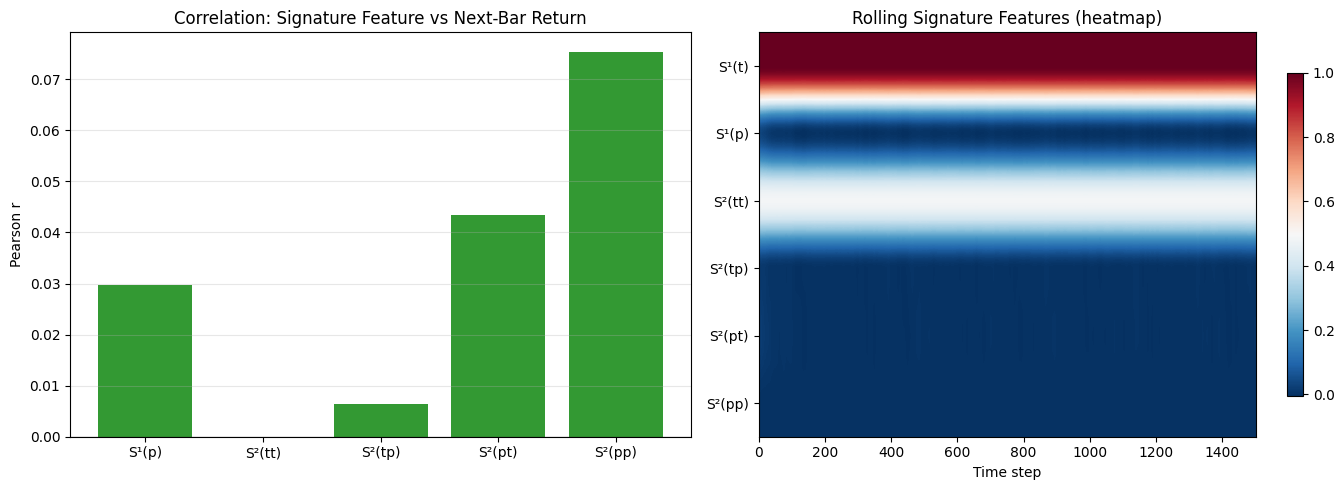


Feature-return correlations (window=40):
  S¹(t)       NaN (constant feature)
  S¹(p)       +0.0298  
  S²(tt)      NaN (constant feature)
  S²(tp)      +0.0064  
  S²(pt)      +0.0434  █
  S²(pp)      +0.0754  ██


In [11]:
def rolling_signature_features(prices: np.ndarray, window: int = 30, depth: int = 2) -> np.ndarray:
    """Extract path signature features via rolling window."""
    log_p = np.log(prices)
    features = []
    for i in range(window, len(prices)):
        seg = log_p[i - window : i]
        t   = np.linspace(0, 1, len(seg))
        path = np.column_stack([t, seg])
        sig  = path_signature_2d(path, depth=depth)
        features.append(sig)
    return np.array(features)

WINDOW = 40
feature_matrix   = rolling_signature_features(prices, window=WINDOW, depth=2)
next_bar_returns = np.diff(prices)[WINDOW:] / prices[WINDOW:-1]  # align

# Align lengths (feature_matrix has N-WINDOW rows; diff gives N-1-WINDOW)
min_len = min(len(feature_matrix), len(next_bar_returns))
feature_matrix   = feature_matrix[:min_len]
next_bar_returns = next_bar_returns[:min_len]

# Correlations
# Align lengths (feature_matrix has N-WINDOW rows; diff gives N-1-WINDOW)
min_len = min(len(feature_matrix), len(next_bar_returns))
feature_matrix   = feature_matrix[:min_len]
next_bar_returns = next_bar_returns[:min_len]

corrs = [np.corrcoef(feature_matrix[:, j], next_bar_returns)[0, 1]
         for j in range(feature_matrix.shape[1])]

feature_names     = ["S¹(t)", "S¹(p)", "S²(tt)", "S²(tp)", "S²(pt)", "S²(pp)"]
feat_names_short  = feature_names[:len(corrs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation bar chart
colors_corr = ["green" if (not (c != c) and c > 0) else "red" for c in corrs]
axes[0].bar(feat_names_short, corrs, color=colors_corr, alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Correlation: Signature Feature vs Next-Bar Return")
axes[0].set_ylabel("Pearson r"); axes[0].grid(axis="y", alpha=0.3)

# Feature evolution heatmap (subsample)
step     = max(1, len(feature_matrix) // 200)
hm_data  = feature_matrix[::step, :].T
im = axes[1].imshow(hm_data, aspect="auto", cmap="RdBu_r",
                    extent=[0, len(prices), len(corrs)-0.5, -0.5])
axes[1].set_yticks(range(len(feat_names_short)))
axes[1].set_yticklabels(feat_names_short)
axes[1].set_xlabel("Time step"); axes[1].set_title("Rolling Signature Features (heatmap)")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout(); plt.show()
print(f"\nFeature-return correlations (window={WINDOW}):")
for name, c in zip(feat_names_short, corrs):
    if c != c:  # NaN guard
        print(f"  {name:10s}  NaN (constant feature)")
        continue
    bar  = "█" * int(abs(c) * 30)
    sign = "+" if c > 0 else "-"
    print(f"  {name:10s}  {sign}{abs(c):.4f}  {bar}")

<a id="section-11"></a>

## 11. Performance Metrics & Analytics

We backtest the regime-aware signal against a **buy-and-hold** baseline using standard risk-adjusted metrics:

| Metric | Definition |
|--------|-----------|
| **Sharpe** | $\frac{\sqrt{252}\,\bar{r}}{\sigma_r}$ — annualised excess return per unit of total vol |
| **Sortino** | Same numerator but $\sigma_{\text{downside}}$ in denominator |
| **Calmar** | Annualised return ÷ max drawdown |
| **Max Drawdown** | Peak-to-trough equity decline |

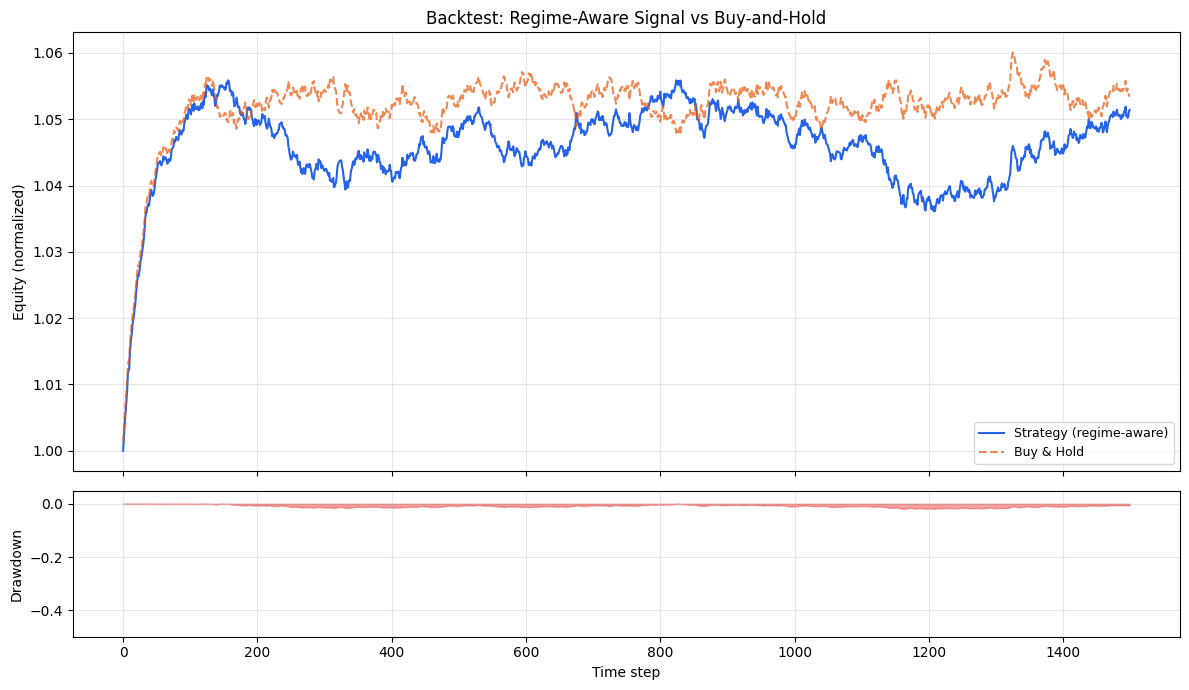


  PERFORMANCE SUMMARY — hfthot-lab-core v1.3.0
                    Strategy Buy & Hold
Metric                                 
Sharpe (annualised)    1.004      1.040
Sortino                1.808      1.797
Calmar                 0.452      0.916
Max Drawdown          -1.87%     -0.96%
Total Return %         5.14%      5.34%


In [12]:
def compute_returns(prices: np.ndarray) -> np.ndarray:
    return np.diff(prices) / prices[:-1]

def sharpe_ratio(returns: np.ndarray, rf: float = 0.0, periods_per_year: int = 252) -> float:
    excess = returns - rf / periods_per_year
    return np.sqrt(periods_per_year) * excess.mean() / (excess.std() + 1e-12)

def sortino_ratio(returns: np.ndarray, rf: float = 0.0, periods_per_year: int = 252) -> float:
    excess = returns - rf / periods_per_year
    downside = returns[returns < 0].std()
    return np.sqrt(periods_per_year) * excess.mean() / (downside + 1e-12)

def max_drawdown(equity_curve: np.ndarray) -> float:
    running_max = np.maximum.accumulate(equity_curve)
    dd = (equity_curve - running_max) / running_max
    return dd.min()

def calmar_ratio(returns: np.ndarray, periods_per_year: int = 252) -> float:
    equity = (1 + returns).cumprod()
    ann_return = (equity[-1] ** (periods_per_year / len(returns))) - 1
    mdd = abs(max_drawdown(equity))
    return ann_return / (mdd + 1e-12)

def backtest_signals(prices: np.ndarray, signals: np.ndarray) -> np.ndarray:
    """Return strategy returns series."""
    rets = np.zeros(len(prices) - 1)
    position = 0
    for t in range(1, len(prices)):
        position = signals[t - 1] if signals[t - 1] != 0 else position
        rets[t - 1] = position * (prices[t] / prices[t - 1] - 1)
    return rets

strat_returns = backtest_signals(prices, signals)
bh_returns    = compute_returns(prices)

strat_equity  = np.cumprod(1 + strat_returns)
bh_equity     = np.cumprod(1 + bh_returns)

# Plot equity curves
fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})
ax_eq.plot(strat_equity, label="Strategy (regime-aware)", color="#2563EB")
ax_eq.plot(bh_equity,    label="Buy & Hold",               color="#EA580C", alpha=0.7, ls="--")
ax_eq.set_ylabel("Equity (normalized)"); ax_eq.legend(fontsize=9)
ax_eq.set_title("Backtest: Regime-Aware Signal vs Buy-and-Hold")
ax_eq.grid(alpha=0.3)

# Drawdown chart for strategy
running_max_s = np.maximum.accumulate(strat_equity)
dd_s = (strat_equity - running_max_s) / running_max_s
ax_dd.fill_between(range(len(dd_s)), dd_s, color="#EF4444", alpha=0.5, label="Strategy DD")
ax_dd.set_ylabel("Drawdown"); ax_dd.set_xlabel("Time step")
ax_dd.set_ylim(-0.5, 0.05); ax_dd.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Print performance table
metrics = {
    "Metric": ["Sharpe (annualised)", "Sortino", "Calmar", "Max Drawdown", "Total Return %"],
    "Strategy": [
        f"{sharpe_ratio(strat_returns):.3f}",
        f"{sortino_ratio(strat_returns):.3f}",
        f"{calmar_ratio(strat_returns):.3f}",
        f"{100*max_drawdown(strat_equity):.2f}%",
        f"{100*(strat_equity[-1]-1):.2f}%",
    ],
    "Buy & Hold": [
        f"{sharpe_ratio(bh_returns):.3f}",
        f"{sortino_ratio(bh_returns):.3f}",
        f"{calmar_ratio(bh_returns):.3f}",
        f"{100*max_drawdown(bh_equity):.2f}%",
        f"{100*(bh_equity[-1]-1):.2f}%",
    ],
}
df_perf = pd.DataFrame(metrics).set_index("Metric")
print("\n" + "="*50)
print("  PERFORMANCE SUMMARY — hfthot-lab-core v1.3.0")
print("="*50)
print(df_perf.to_string())

<a id="section-12"></a>

## 12. Summary & Next Steps

This notebook demonstrated the core capabilities of **hfthot-lab-core v1.3.0**:

| Section | What Was Shown |
|---------|----------------|
| §1–2 | Rust extension setup, Chiarella-He mathematical foundations |
| §3 | Agent-based price simulation — Rust vs. Python fallback |
| §4 | Bifurcation diagram: stable/mixed/unstable regimes |
| §5 | Phase portraits & stability heatmaps |
| §6 | Rolling regime detection with visual regime shading |
| §7 | Connector abstraction — same interface as live data loaders |
| §8 | Regime-aware trading signals (momentum + mean-reversion) |
| §9 | Chen path signatures & lead-lag transform theory |
| §10 | Rolling signature feature extraction & return correlation |
| §11 | Full backtest with Sharpe, Sortino, Calmar & drawdown metrics |

### Public API Highlights

```python
import hfthot_lab_core as hft

# Simulation
result = hft.simulate_chiarella_py(initial_price=95, fundamental_price=100,
                                    n_steps=1500, beta_f=0.5, beta_c=1.0,
                                    gamma=1.5, mu=0.1, sigma=0.05)

# Path signatures
features = hft.prices_to_signature_features_py(prices, depth=2)

# Backtest
metrics = hft.backtest_strategy_rust(signals, prices, config)
```

### Explore More Notebooks

| Notebook | Topic |
|----------|-------|
| `geometric_arbitrage.ipynb` | Hodge decomposition & cycle curvature |
| `kalman_filter_market_making.ipynb` | Kalman filter-based market making |
| `mean_field_games_portfolio.ipynb` | Mean-field game portfolio optimization |
| `path_signatures_trading.ipynb` | Deep dive into path signature trading features |

> **License:** MIT — See [LICENSE](../../LICENSE) for full details.

In [13]:
# Summary of key results from this notebook run
import datetime

print(f'hfthot-lab-core Chiarella Lab — Run Summary')
print('=' * 50)
print(f'  Run date         : {datetime.date.today().isoformat()}')
print(f'  Simulation steps : {len(prices)}')
print(f'  Final price      : {prices[-1]:.4f}  (fund={p_fund})')
print(f'  Ann. vol         : {float(np.std(np.diff(prices)) * np.sqrt(252)):.4f}')
print(f'  Strategy Sharpe  : {sharpe_ratio(strat_returns):.3f}')
print(f'  Buy&Hold Sharpe  : {sharpe_ratio(bh_returns):.3f}')
print(f'  Max Drawdown     : {100*max_drawdown(strat_equity):.2f}%')
print(f'  Total Return     : {100*(strat_equity[-1]-1):.2f}%')
print('=' * 50)
print('All sections completed successfully.')


hfthot-lab-core Chiarella Lab — Run Summary
  Run date         : 2026-03-13
  Simulation steps : 1501
  Final price      : 100.0735  (fund=100.0)
  Ann. vol         : 0.8406
  Strategy Sharpe  : 1.004
  Buy&Hold Sharpe  : 1.040
  Max Drawdown     : -1.87%
  Total Return     : 5.14%
All sections completed successfully.
